# Automatic Detection of Scoria Cones from DEMs

**Course:** Computational Vision — UniGe<br>
**Student:** Gabriele Berruti (4791919)

**Goal.** Detect scoria cones from single-channel Digital Elevation Models (DEMs).<br>
**Distinctive contribution.** Separate *nested / adjacent* cones that point-based blob detectors merge into a single detection, via a watershed segmentation of the crater depressions.

**Datasets:**<br>
*El Hierro*: 5 m, with ground truth (development / validation).<br>
*Etna*: 2 m, noisy ground truth (stress test).<br>
*Jeju*: 10 m, no ground truth (qualitative / unsupervised).

---

## Step 0 — DEM loading and inspection

The raw DEM is a single-channel raster whose pixel value is an elevation in metres (a
*range image*, cf. slide deck `04_3Dvision_small` p.3). <br>
Before any analysis we open each
DEM, convert the dataset-specific *nodata* sentinel to `NaN`, and inspect shape,
resolution, dtype and elevation range.

*Test:* resolutions must come out as 2 / 5 / 10 m and the max elevations must match the
real volcanoes (Etna ~3.3 km, El Hierro ~1.5 km, Jeju/Hallasan ~1.95 km).

In [1]:
import numpy as np
import rasterio
from pathlib import Path

DATA_DIR = Path("..") / "CinderConesDataPack"

DEM_PATHS = {
    "El Hierro": DATA_DIR / "ElHierro/DEM/dem5m/Hierro.tif",
    "Etna":      DATA_DIR / "Etna/DEM2m/DEM 2 m Etna-001.tif",
    "Jeju":      DATA_DIR / "Jeju/Dem10m/Raster Jeju 5k.tif",
}

def load_dem(path):
    """Load a georeferenced DEM; nodata -> NaN. Returns (dem, res, crs)."""
    with rasterio.open(path) as src:
        dem = src.read(1, masked=True).filled(np.nan).astype(np.float32)
        res, crs = src.res, src.crs
    return dem, res, crs

**Column legend.**<br>
*dataset*: study area.<br>
*H × W*: raster height × width in pixels (matrix rows × columns).<br>
*Mpx*: total number of pixels in millions (H·W), a proxy for the memory footprint.<br>
*NaN%*: share of pixels that were *nodata* and got mapped to `NaN` (terrain outside the raster/island, ignored by every later step).<br>
*res(m)*: spatial resolution, i.e. the ground size of a single pixel in metres.<br>
*dtype*: numeric type of the elevation values.<br>
*z_max(m)*: maximum elevation in metres, used as a sanity check against the real volcano.

In [2]:
hdr = f"{'dataset':10} {'H x W':>15} {'Mpx':>7} {'NaN%':>6} {'res(m)':>7} {'dtype':>8} {'z_max(m)':>9}"
print(hdr); print("-" * len(hdr))
for name, path in DEM_PATHS.items():
    dem, res, crs = load_dem(path)
    H, W = dem.shape
    nan_pct = 100 * np.isnan(dem).sum() / dem.size
    zmax = np.nanmax(dem)
    print(f"{name:10} {f'{H} x {W}':>15} {H*W/1e6:7.1f} {nan_pct:5.0f}% {res[0]:7.1f} "
          f"{str(dem.dtype):>8} {zmax:9.1f}")

dataset              H x W     Mpx   NaN%  res(m)    dtype  z_max(m)
--------------------------------------------------------------------
El Hierro      5081 x 5681    28.9    40%     5.0  float32    1499.8
Etna         27756 x 25717   713.8    25%     2.0  float32    3324.1
Jeju           4364 x 7761    33.9    27%    10.0  float32    1945.0


---

## Step 0.5 — Visual inspection of data and labels

Before deriving any channel, we *look* at the data (cf. methodology: observe before
transforming). We use **El Hierro** (clean ground truth). Two observations drive the
preprocessing:
<br>
1. the **raw DEM is almost flat** to the eye, while the Eduard renderings (NE/NW shading,
   texture) make the cones pop &rarr; we will need derived channels (Step 1);
2. the **ground truth** marks crater outlines, and several cones are **adjacent / nested**
   &rarr; this is exactly the case our watershed step targets.

**What the panels mean.**<br>
- *Raw DEM*: the original elevation grid — each pixel is the terrain height in metres, nothing computed yet. It looks flat because a cone is only tens of metres tall compared with the whole island's range.<br>
- *Eduard renderings*: relief-shaded views of the terrain produced by the *Eduard* relief-shading tool and shipped with the dataset; they simulate how the surface looks under light.<br>
- *NE / NW shading (hillshade)*: the terrain lit by a simulated sun from the North-East / North-West — slopes facing the light are bright, those facing away are dark, which makes the 3D shape visible. <br>
Two opposite directions are provided so no slope stays hidden in shadow.<br>
*Texture shading*: a light-direction-independent rendering that emphasises fine surface detail.

Figures are saved to `../Latex/figures/` for the report.

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio
from rasterio.transform import rowcol
import geopandas as gpd

FIG_DIR = Path("..") / "Latex" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

HIERRO_DEM  = DATA_DIR / "ElHierro/DEM/dem5m/Hierro.tif"
HIERRO_REND = DATA_DIR / "ElHierro/Renderings"
HIERRO_SHP  = DATA_DIR / "ElHierro/Coni/Cones.shp"

def load_norm(path):
    """Load a single-band rendering, normalise to [0,1] via 1-99 percentile clip."""
    with rasterio.open(path) as s:
        a = s.read(1).astype(np.float32)
    a = np.where(np.isfinite(a), a, np.nan)
    lo, hi = np.nanpercentile(a, [1, 99])
    return np.clip((a - lo) / (hi - lo + 1e-9), 0, 1)

dem_h, _, _ = load_dem(HIERRO_DEM)
ne  = load_norm(HIERRO_REND / "Hierro-Eduard-Analytical-NE.tiff")
nw  = load_norm(HIERRO_REND / "Hierro-Eduard-Analytical-NW.tiff")
tex = load_norm(HIERRO_REND / "Hierro-Eduard-Texture.tiff")
with rasterio.open(HIERRO_DEM) as s:
    transform_h = s.transform

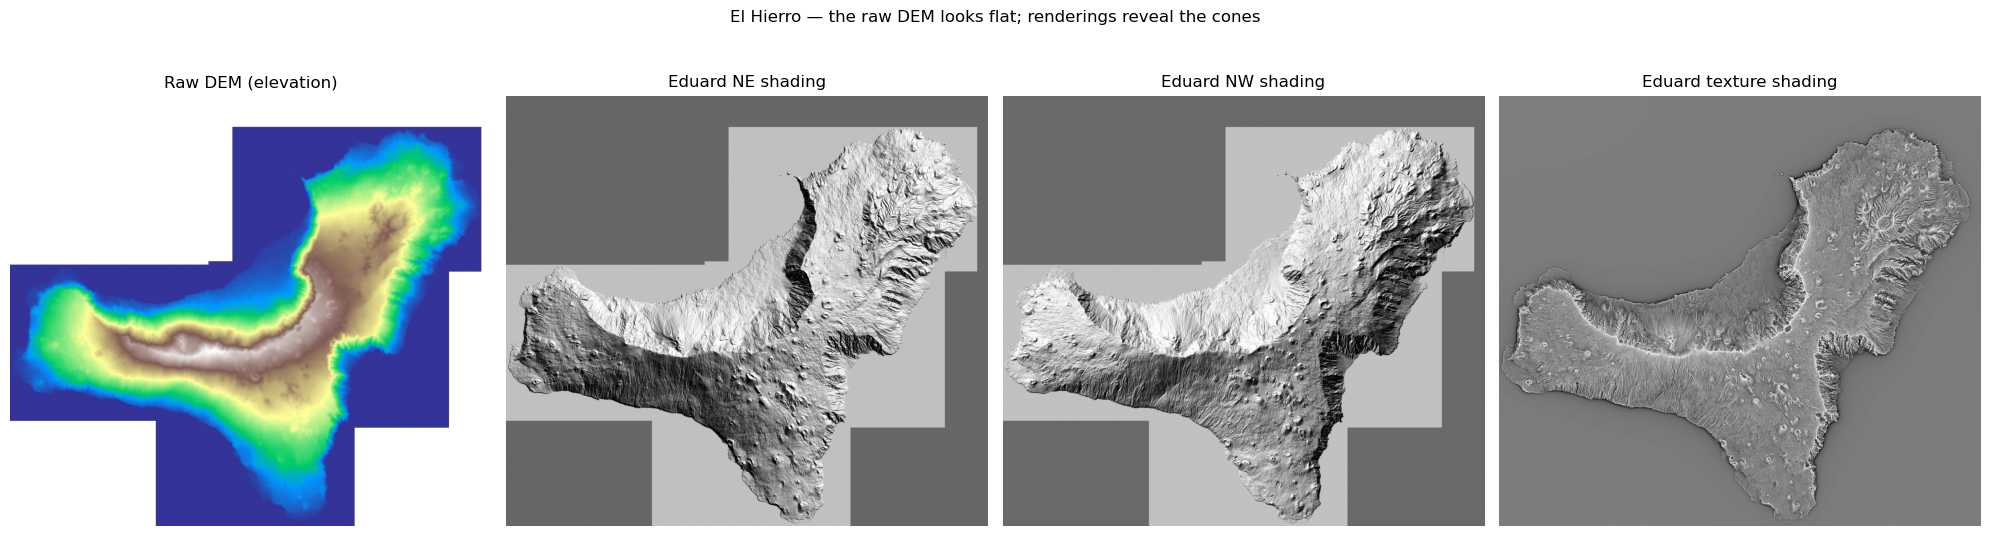

In [4]:
# Figure 1 — raw DEM vs Eduard renderings
fig, ax = plt.subplots(1, 4, figsize=(20, 5.5))
ax[0].imshow(dem_h, cmap="terrain"); ax[0].set_title("Raw DEM (elevation)")
ax[1].imshow(ne,  cmap="gray");      ax[1].set_title("Eduard NE shading")
ax[2].imshow(nw,  cmap="gray");      ax[2].set_title("Eduard NW shading")
ax[3].imshow(tex, cmap="gray");      ax[3].set_title("Eduard texture shading")
for a in ax: a.axis("off")
fig.suptitle("El Hierro — the raw DEM looks flat; renderings reveal the cones", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_channels.png", dpi=120, bbox_inches="tight")
plt.show()

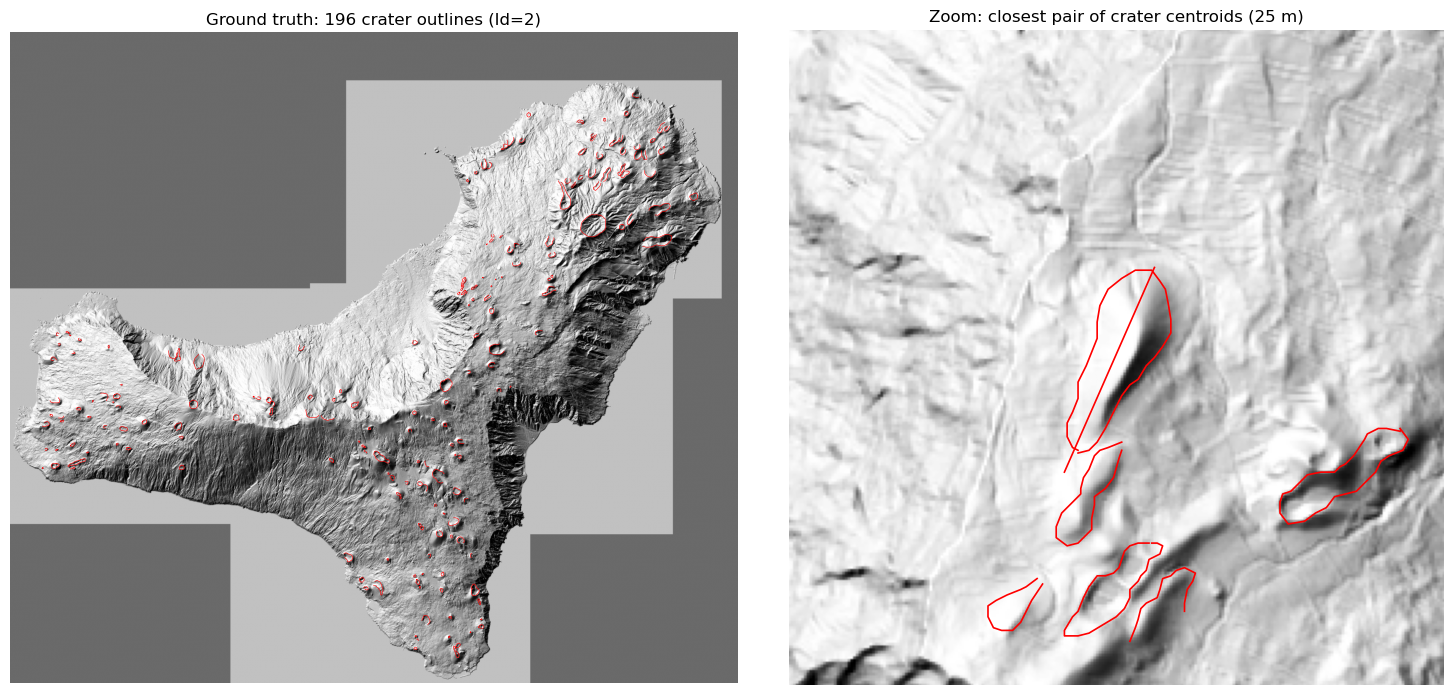

Craters: 196 | closest pair distance: 25 m


In [5]:
# Figure 2 — ground-truth crater outlines + zoom on the closest pair
gt = gpd.read_file(HIERRO_SHP)
craters = gt[gt["Id"] == 2]
cent = np.array([[g.centroid.x, g.centroid.y] for g in craters.geometry])

# closest pair of craters (motivates the separation contribution)
from scipy.spatial import cKDTree
d, idx = cKDTree(cent).query(cent, k=2)
i = int(np.argmin(d[:, 1]))
cx, cy = cent[i]
r0, c0 = rowcol(transform_h, cx, cy)
half = 120  # pixels (~600 m at 5 m/px)

def outline_px(geom):
    xs, ys = geom.xy
    rr, cc = rowcol(transform_h, list(xs), list(ys))
    return np.asarray(cc), np.asarray(rr)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(nw, cmap="gray")
for g in craters.geometry:
    cc, rr = outline_px(g); ax[0].plot(cc, rr, color="red", lw=0.4)
ax[0].set_title(f"Ground truth: {len(craters)} crater outlines (Id=2)"); ax[0].axis("off")

ax[1].imshow(nw, cmap="gray")
for g in craters.geometry:
    cc, rr = outline_px(g); ax[1].plot(cc, rr, color="red", lw=1.2)
ax[1].set_xlim(c0 - half, c0 + half); ax[1].set_ylim(r0 + half, r0 - half)
ax[1].set_title("Zoom: closest pair of crater centroids (25 m)"); ax[1].axis("off")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_gt.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Craters: {len(craters)} | closest pair distance: {d[i,1]:.0f} m")

**The adjacent / nested cases, up close.** <br>
The gallery below isolates every crater whose
nearest neighbour is closer than the sum of the two radii (their outlines overlap). 

These
are the cases a point-based blob detector collapses into a single detection, and exactly
what the watershed step must split apart.

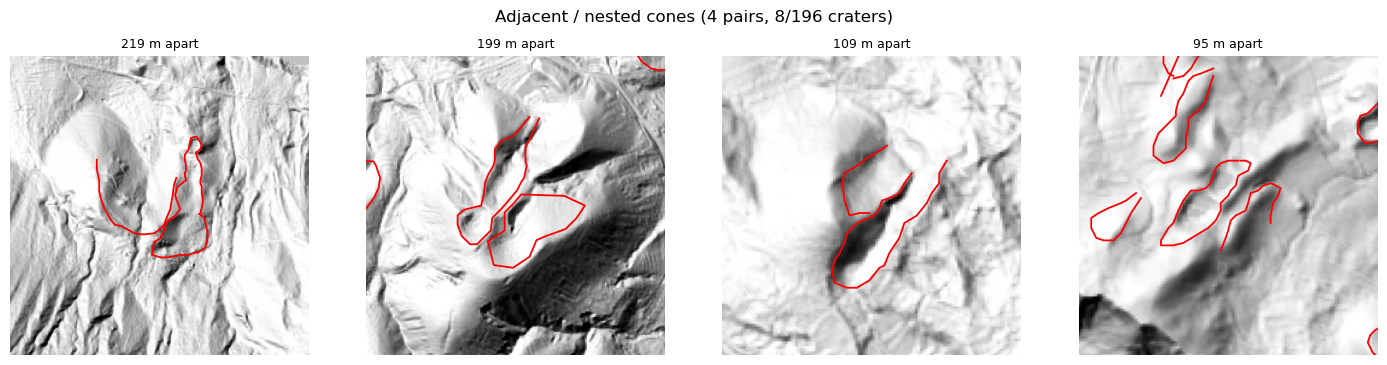

In [6]:
# Gallery: all adjacent / nested crater pairs (outlines overlap)
from shapely.geometry import Polygon
from scipy.spatial import cKDTree

def _equiv_radius(geom):
    try:
        a = Polygon(geom.coords).area
        return np.sqrt(a / np.pi) if a > 0 else np.nan
    except Exception:
        return np.nan

cra = gt[gt["Id"] == 2].reset_index(drop=True)
rad = np.array([_equiv_radius(g) for g in cra.geometry])
cen = np.array([[g.centroid.x, g.centroid.y] for g in cra.geometry])
dist, idx = cKDTree(cen).query(cen, k=2)
adj = dist[:, 1] < (rad + rad[idx[:, 1]])

# unique adjacent pairs
pairs = sorted({frozenset((i, int(idx[i, 1]))) for i in np.where(adj)[0]}, key=min)
pairs = [tuple(p) for p in pairs]

ncols = min(4, len(pairs)); nrows = int(np.ceil(len(pairs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.6 * nrows))
axes = np.atleast_1d(axes).ravel()
for k, (i, j) in enumerate(pairs):
    ax = axes[k]
    mx, my = (cen[i] + cen[j]) / 2
    rr, cc = rowcol(transform_h, mx, my)
    half = int(max(60, 2.2 * (rad[i] + rad[j]) / 5.0))   # 5 m/px
    ax.imshow(nw, cmap="gray")
    for g in cra.geometry:
        gc, gr = outline_px(g); ax.plot(gc, gr, color="red", lw=1.3)
    ax.set_xlim(cc - half, cc + half); ax.set_ylim(rr + half, rr - half)
    dij = np.linalg.norm(cen[i] - cen[j])
    ax.set_title(f"{dij:.0f} m apart", fontsize=9); ax.axis("off")
for k in range(len(pairs), len(axes)):
    axes[k].axis("off")
fig.suptitle(f"Adjacent / nested cones ({len(pairs)} pairs, {int(adj.sum())}/{len(cra)} craters)", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_adjacent.png", dpi=120, bbox_inches="tight")
plt.show()

**Ground-truth quality.** The crater outlines (Id=2) are *dirty*, which is why we will
rely on crater **centroids** (plus an approximate radius) rather than the exact outline shape:
<br>
- **191 of 196 are open** polylines (only 5 are closed, i.e. first point = last point);<br>
- the **start–end gap** has median **41 m**, up to **555 m**;<br>
- the **vertex count** has median 19, but **some outlines have only 2 points** (a plain segment).

**Label semantics (data-driven).** El Hierro stores three feature types in one shapefile,
identified by `Id` and confirmed by the geometry tests above:
<br>
- *Id=1 — base*: large, roundish outline (median length 846 m, aspect 1.3) that **encloses the
  crater in 98% of cones**;<br>
- *Id=2 — crater rim*: smaller roundish outline (457 m, aspect 1.5) — **our detection target**;<br>
- *Id=3 — fissure*: a short, strongly **elongated** segment (median 2 vertices, aspect 8.3) that
  always carries a non-zero azimuth;<br>
- *`Prj_Az`*: the **fissure azimuth** in degrees (0–359), non-zero only for Id=3;<br>
- *`pericolosi`*: a hazard level (values 0/1/2).

In [7]:
# Ground-truth quality and label semantics (tests)
from shapely.geometry import Polygon

gtf = gpd.read_file(HIERRO_SHP)

def n_verts(g):  return len(g.xy[0])
def is_closed(g):
    x, y = g.xy; return x[0] == x[-1] and y[0] == y[-1]
def gap(g):
    x, y = g.xy; return ((x[0]-x[-1])**2 + (y[0]-y[-1])**2) ** 0.5
def aspect(g):
    try:
        x, y = g.minimum_rotated_rectangle.exterior.xy
        p = np.array(list(zip(x, y)))[:-1]
        s = [np.linalg.norm(p[i]-p[(i+1) % 4]) for i in range(4)]
        return max(s) / (min(s) + 1e-9)
    except Exception:
        return np.nan
def area(g):
    try: return Polygon(g.coords).area
    except Exception: return np.nan

# (a) crater outline quality (Id=2)
cra = gtf[gtf["Id"] == 2]
nopen = sum(not is_closed(g) for g in cra.geometry)
gaps  = np.array([gap(g) for g in cra.geometry])
verts = np.array([n_verts(g) for g in cra.geometry])
print("Crater outlines (Id=2):", len(cra), "| open", nopen, "| closed", len(cra)-nopen)
print(f"  start-end gap (m): median {np.median(gaps):.0f} | max {gaps.max():.0f}")
print(f"  vertices: median {int(np.median(verts))} | min {verts.min()}")
print()
# (b) label semantics per Id
print("Id  feature   n     verts  len(m)  aspect  Prj_Az!=0")
names = {1: "base", 2: "crater", 3: "fissure"}
for i in [1, 2, 3]:
    s = gtf[gtf["Id"] == i]
    v  = int(np.median([n_verts(g) for g in s.geometry]))
    L  = np.median(s.geometry.length.values)
    a  = np.nanmedian([aspect(g) for g in s.geometry])
    nz = 100 * np.count_nonzero(s["Prj_Az"].values) / len(s)
    print(f"{i}   {names[i]:8} {len(s):4}  {v:5}  {L:6.0f}  {a:6.2f}  {nz:5.0f}%")
print()
# (c) nesting: base larger than crater
big = tot = 0
for _, grp in gtf.groupby("coni"):
    a1 = grp[grp.Id == 1].geometry.apply(area)
    a2 = grp[grp.Id == 2].geometry.apply(area)
    if len(a1) and len(a2):
        tot += 1; big += a1.mean() > a2.mean()
print(f"Base larger than crater: {big}/{tot} cones ({100*big/tot:.0f}%)")

Crater outlines (Id=2): 196 | open 191 | closed 5
  start-end gap (m): median 40 | max 556
  vertices: median 19 | min 2

Id  feature   n     verts  len(m)  aspect  Prj_Az!=0
1   base      151     29     846    1.29      0%
2   crater    196     19     457    1.47      0%
3   fissure   171      2     272    8.32    100%



Base larger than crater: 145/148 cones (98%)


**How to read the output above.** The three printed blocks answer three questions about the labels.
<br>

- **(a) Crater outline quality** — of the 196 crater outlines (`Id=2`), **191 are *open*** (first vertex ≠ last vertex) and only 5 close up. The *start–end gap* is the straight-line distance between the first and last vertex of an outline (median **40 m**, up to **556 m** → some outlines are very far from closing), and the *vertex count* drops to as low as **2** (a plain segment). Take-away: the outlines are too unreliable to use as exact shapes, so we work with crater **centroids + an approximate radius** instead.<br>

- **(b) Per-label table** — one row per `Id`, median values across all features of that type. Columns:<br>
   • *n*: how many features carry that `Id`;<br>
   • *verts*: median number of vertices per outline (shape detail);<br>
   • *len(m)*: median outline length in metres (size);<br>
   • *aspect*: elongation of the minimum bounding rectangle, longer side / shorter side (**≈1 = round**, **≫1 = stretched**);<br>
   • *Prj_Az≠0*: share of features whose azimuth field is non-zero.<br>
  Reading across the rows the labels separate cleanly: **Id=1** is long and round (846 m, aspect 1.3) → the cone **base**; **Id=2** is medium and round (457 m, aspect 1.5) → the **crater rim**, our target; **Id=3** has just 2 vertices, aspect **8.3** and **100% non-zero azimuth** → a **fissure** (an elongated line with a direction).<br>

- **(c) Nesting check** — for **145 of 148 cones (98%)** the base outline (`Id=1`) has a larger area than its crater (`Id=2`), confirming the geometry we expect: the small crater sits **inside** the wider cone base.


**Observation (what these data fix for the pipeline).** The geometry tests settle the three labels and turn them into three concrete decisions:
<br>

- the **crater** (`Id=2`) is the **detection target** — it is the only label present on *every* cone (196), and since its outlines are open/dirty we represent each crater by its **centroid + equivalent radius**, not by the polygon;<br>
- the **base** (`Id=1`) encloses the crater in **98%** of cones: this containment *is* the nested configuration our contribution must preserve, and it offers a free sanity check on a detection (a real crater sits inside a wider, rounder base);<br>
- the **fissure** (`Id=3`), a short segment carrying a real azimuth (`Prj_Az`), is **not** a target but feeds the qualitative cone–fissure alignment of the bonus step.

Note also that the labels are **not equinumerous** (151 base / 196 crater / 171 fissure): annotations are incomplete, so we anchor the whole pipeline on the complete crater set rather than on bases or fissures.

---

## Step 0.6 — Quick data analysis

Three cheap checks on El Hierro that *parameterise* the later steps instead of guessing:
<br>
**1. Cone size distribution** &rarr; the equivalent radius of each crater fixes the
**scale range of the LoG detector** (Step&nbsp;4) and the watershed marker scale.<br>
**2. Nearest-neighbour distances** &rarr; how many cones sit closer than the sum of their
radii, i.e. **adjacent / nested** — this quantifies the problem the watershed step solves.<br>
**3. Rendering &harr; DEM alignment** &rarr; safety check that the Eduard renderings share
the DEM grid (same shape and transform), so overlays are pixel-exact.

In [8]:
# 3. Rendering <-> DEM alignment
with rasterio.open(HIERRO_DEM) as s:
    dem_shape, dem_tr = (s.height, s.width), s.transform
print(f"DEM            shape={dem_shape}")
for fn in ["Hierro-Eduard-Analytical-NE.tiff",
           "Hierro-Eduard-Analytical-NW.tiff",
           "Hierro-Eduard-Texture.tiff"]:
    with rasterio.open(HIERRO_REND / fn) as s:
        ok = (s.height, s.width) == dem_shape and s.transform == dem_tr
        print(f"{fn:38} shape={(s.height,s.width)}  {'aligned' if ok else 'MISALIGNED'}")

DEM            shape=(5081, 5681)
Hierro-Eduard-Analytical-NE.tiff       shape=(5081, 5681)  aligned
Hierro-Eduard-Analytical-NW.tiff       shape=(5081, 5681)  aligned
Hierro-Eduard-Texture.tiff             shape=(5081, 5681)  aligned


Craters: 196
Radius (m)  -> min 6 | 5th 20 | median 71 | 95th 174 | max 457
Suggested LoG radius range: 20-174 m
NN distance (m) -> min 25 | median 418
Adjacent/nested craters (NN < r_i+r_j): 8 / 196 (4%)


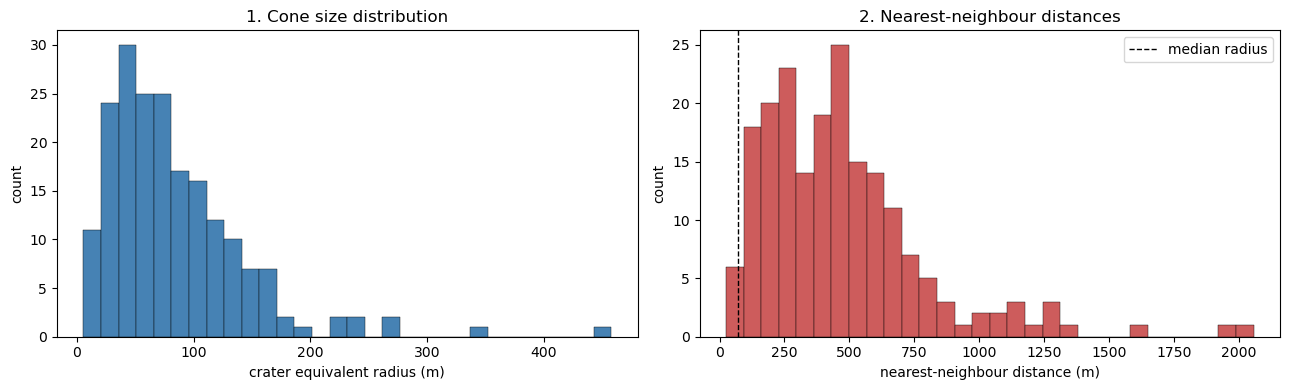

In [9]:
# 1+2. Cone sizes and nearest-neighbour distances (El Hierro craters, Id=2)
from shapely.geometry import Polygon
from scipy.spatial import cKDTree

gt = gpd.read_file(HIERRO_SHP)
craters = gt[gt["Id"] == 2].reset_index(drop=True)

def equiv_radius(geom):
    """Radius of the circle with the same area as the closed crater outline (m)."""
    try:
        a = Polygon(geom.coords).area
        return np.sqrt(a / np.pi) if a > 0 else np.nan
    except Exception:
        return np.nan

radii = np.array([equiv_radius(g) for g in craters.geometry])
cent  = np.array([[g.centroid.x, g.centroid.y] for g in craters.geometry])

d, idx = cKDTree(cent).query(cent, k=2)
nn_dist, nn_idx = d[:, 1], idx[:, 1]

# adjacency: centroids closer than the sum of the two radii (outlines touch/overlap)
adj = nn_dist < (radii + radii[nn_idx])
n_adj = int(np.nansum(adj))

r = radii[np.isfinite(radii)]
print(f"Craters: {len(craters)}")
print(f"Radius (m)  -> min {r.min():.0f} | 5th {np.percentile(r,5):.0f} | "
      f"median {np.median(r):.0f} | 95th {np.percentile(r,95):.0f} | max {r.max():.0f}")
print(f"Suggested LoG radius range: {np.percentile(r,5):.0f}-{np.percentile(r,95):.0f} m")
print(f"NN distance (m) -> min {nn_dist.min():.0f} | median {np.median(nn_dist):.0f}")
print(f"Adjacent/nested craters (NN < r_i+r_j): {n_adj} / {len(craters)} "
      f"({100*n_adj/len(craters):.0f}%)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(r, bins=30, color="steelblue", edgecolor="k", lw=0.3)
ax[0].set_xlabel("crater equivalent radius (m)"); ax[0].set_ylabel("count")
ax[0].set_title("1. Cone size distribution")
ax[1].hist(nn_dist, bins=30, color="indianred", edgecolor="k", lw=0.3)
ax[1].axvline(np.median(r), color="k", ls="--", lw=1, label="median radius")
ax[1].set_xlabel("nearest-neighbour distance (m)"); ax[1].set_ylabel("count")
ax[1].set_title("2. Nearest-neighbour distances"); ax[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_data_stats.png", dpi=120, bbox_inches="tight")
plt.show()

**Reading the numbers.**<br>
*196 craters*: the number of crater annotations in the El Hierro ground truth.<br>
*Radius*: cones span a wide size range — the smallest crater is ~6 m, half are below **71 m**, and 90% fall between **20 and 174 m** (largest 457 m).<br>
*LoG range 20–174 m*: we will look for blobs only at these scales (the 5th–95th percentile), ignoring the rare tiny/huge outliers.<br>
*NN distance*: cones are typically **~418 m** apart, but the two closest sit only **25 m** apart.<br>
*Adjacent/nested 8/196 (4%)*: 8 craters have a neighbour so close that their outlines overlap — these are the merging cases the watershed step must separate.

**Observation (what these three checks fix for the pipeline).** Put together, the measurements set three things at once:
<br>

- **Alignment** — the Eduard renderings share the DEM grid exactly (same shape and transform), so every DEM-derived channel and the supplied shadings can be **stacked as co-registered inputs**, with no resampling;<br>
- **Scale** — the crater sizes fix the **LoG search range to 20–174 m** (5th–95th percentile, median 71 m): the detector looks only at these radii and ignores the rare tiny/huge outliers;<br>
- **Difficulty** — only **8/196 cones (4%)** have overlapping outlines, but this 4% is exactly the population a point-based detector **merges into a single response**; it is the quantitative target the watershed step is built to recover.

In short, these numbers *parameterise* the detector (scale range), *guarantee* clean multi-channel inputs (alignment), and *size* the problem the contribution must solve (the 4% adjacent/nested cones).

---

## Step 1 — Morphometric channels: slope, aspect, roughness

From the single elevation band we derive three channels that make the cones visible, using
the **image gradient** (deck `01_image_processing`, p.13):
<br>
- **slope** $=\arctan\sqrt{g_x^2+g_y^2}$ (degrees) — steepness of the terrain;<br>
- **aspect** $=\operatorname{atan2}(g_y,g_x)$ — the direction the slope faces;<br>
- **roughness** $=$ local standard deviation in a $k\times k$ window — surface texture.

These three channels (plus the texture rendering) are the input of every later step.
*Test:* slope is markedly higher on the crater rims than on the background, and the aspect
rotates through $360^\circ$ around a cone (radial pattern).

In [10]:
from scipy.ndimage import sobel, uniform_filter

def compute_slope(dem, res):
    """Slope in degrees from the Sobel gradient magnitude."""
    f = np.nan_to_num(dem)
    gx = sobel(f, axis=1) / (8 * res[0])
    gy = sobel(f, axis=0) / (8 * res[1])
    slope = np.degrees(np.arctan(np.hypot(gx, gy)))
    slope[np.isnan(dem)] = np.nan
    return slope

def compute_aspect(dem, res):
    """Aspect (gradient orientation) in degrees, 0-360."""
    f = np.nan_to_num(dem)
    gx = sobel(f, axis=1) / (8 * res[0])
    gy = sobel(f, axis=0) / (8 * res[1])
    aspect = np.degrees(np.arctan2(gy, gx)) % 360
    aspect[np.isnan(dem)] = np.nan
    return aspect

def compute_roughness(dem, window=5):
    """Local standard deviation of elevation in a window x window box."""
    f = np.nan_to_num(dem)
    mean   = uniform_filter(f, window)
    meansq = uniform_filter(f * f, window)
    rough  = np.sqrt(np.clip(meansq - mean * mean, 0, None))
    rough[np.isnan(dem)] = np.nan
    return rough

dem_h, res_h, _ = load_dem(HIERRO_DEM)
slope_h = compute_slope(dem_h, res_h)
aspect_h = compute_aspect(dem_h, res_h)
rough_h  = compute_roughness(dem_h, window=5)

# Test: slope on crater rims vs background
craters = gpd.read_file(HIERRO_SHP)
craters = craters[craters["Id"] == 2]
rs = []
for g in craters.geometry:
    xs, ys = g.xy
    rr, cc = rowcol(transform_h, list(xs), list(ys))
    rr = np.clip(rr, 0, slope_h.shape[0]-1); cc = np.clip(cc, 0, slope_h.shape[1]-1)
    rs.extend(slope_h[rr, cc])
rs = np.array(rs, float)
print(f"slope on crater rims : median {np.nanmedian(rs):.1f} deg")
print(f"slope background     : median {np.nanmedian(slope_h):.1f} deg")
print(f"roughness            : median {np.nanmedian(rough_h):.2f} m")

slope on crater rims : median 18.8 deg
slope background     : median 8.1 deg


roughness            : median 1.11 m


**What these numbers mean.** 

The crater rims are about **2.3× steeper** than the surrounding terrain ($18.8^\circ$ vs $8.1^\circ$): slope alone already separates the cone flanks from the flat background, which is why it will drive the morphometric mask of Step 3. 

The background roughness is low (median $1.11$ m), so roughness mostly flags the few rough/built-up spots and serves as a **secondary cue**, not the main one.

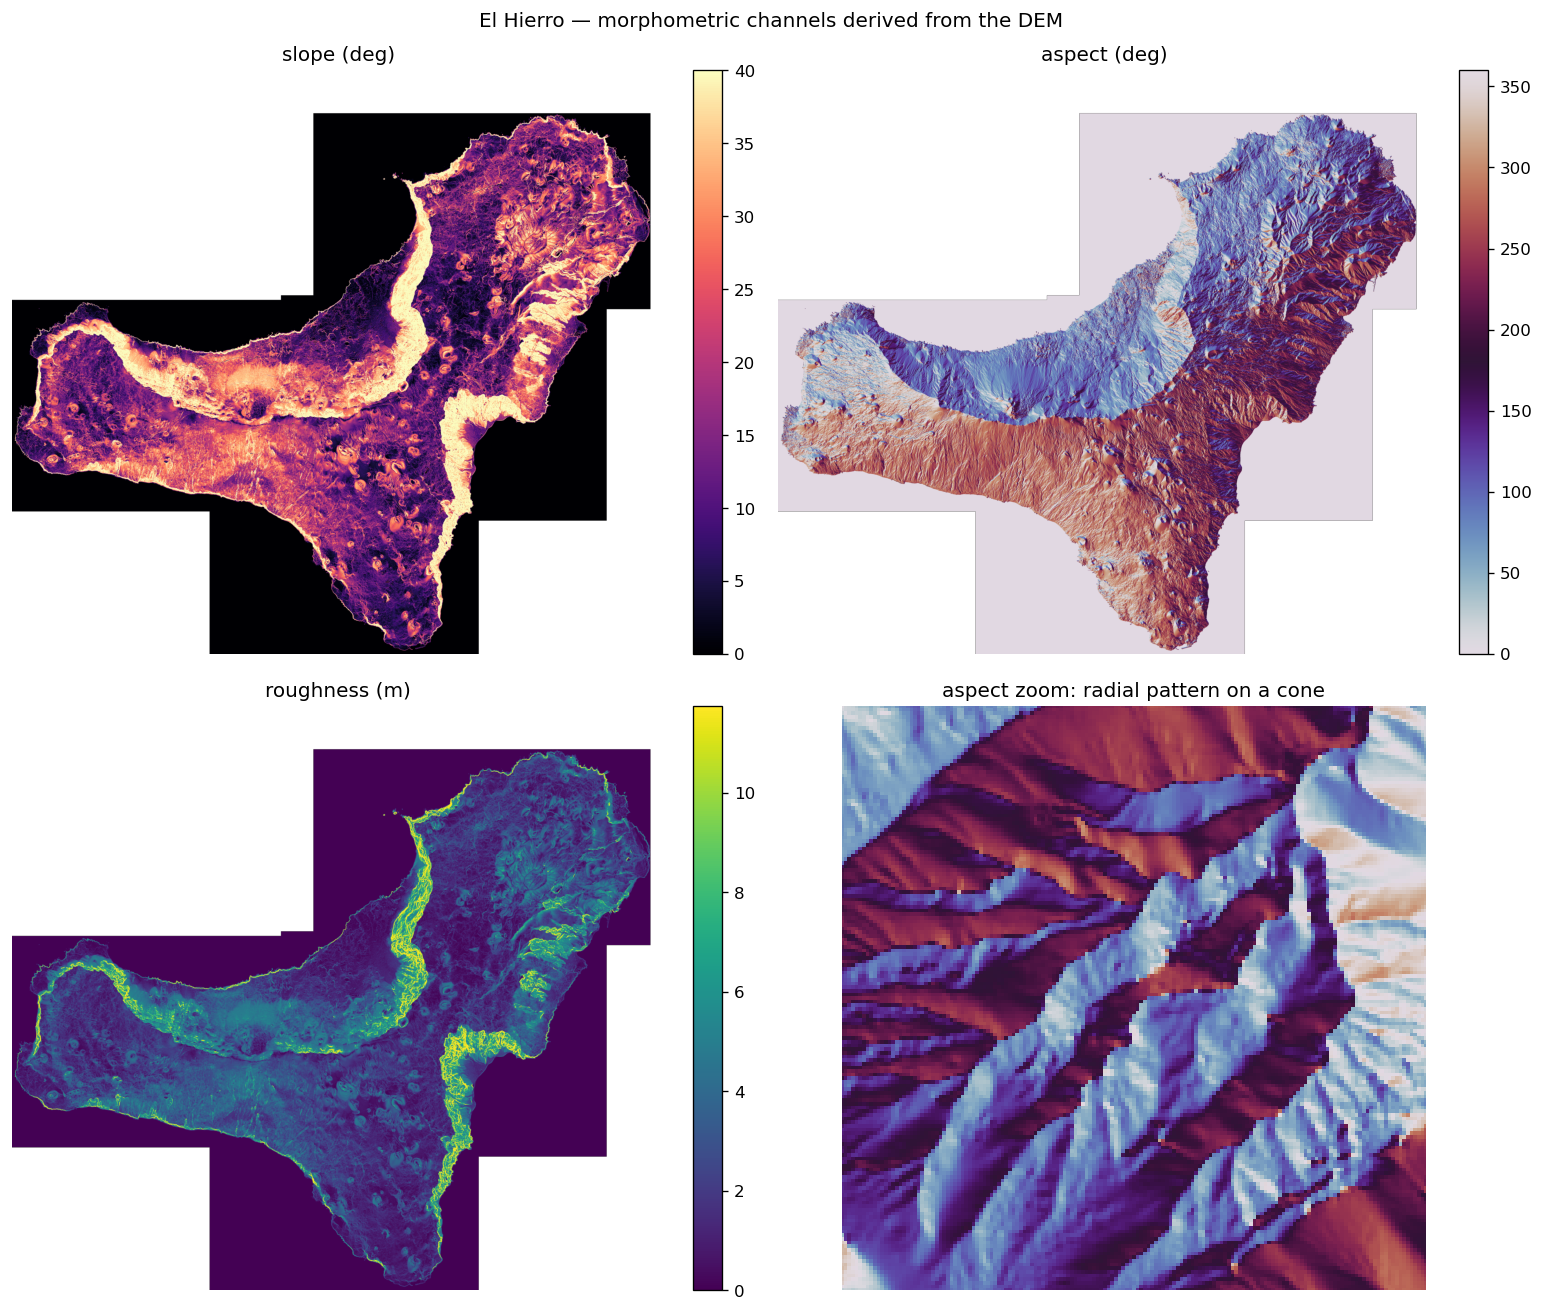

In [11]:
# Visualise the three channels + a zoom showing the radial aspect on one cone (2x2 grid)
cen = np.array([[g.centroid.x, g.centroid.y] for g in craters.geometry])
from shapely.geometry import Polygon
areas = np.array([Polygon(g.coords).area if len(g.xy[0]) > 3 else 0 for g in craters.geometry])
big = int(np.argmax(areas))
br, bc = rowcol(transform_h, cen[big, 0], cen[big, 1]); half = 80

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
ax = axes.ravel()
im0 = ax[0].imshow(slope_h, cmap="magma", vmax=40); ax[0].set_title("slope (deg)")
im1 = ax[1].imshow(aspect_h, cmap="twilight");       ax[1].set_title("aspect (deg)")
im2 = ax[2].imshow(rough_h, cmap="viridis",
                   vmax=np.nanpercentile(rough_h, 99)); ax[2].set_title("roughness (m)")
ax[3].imshow(aspect_h, cmap="twilight")
ax[3].set_xlim(bc-half, bc+half); ax[3].set_ylim(br+half, br-half)
ax[3].set_title("aspect zoom: radial pattern on a cone")
for a, im in zip(ax[:3], [im0, im1, im2]):
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.04)
for a in ax: a.axis("off")
fig.suptitle("El Hierro — morphometric channels derived from the DEM", y=0.99)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_morphometric.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see.** Cones show up as **bright rings** in slope/roughness and as **radial colour wheels** in aspect (one full hue rotation per cone, clear in the zoom). The one catch: the **coastal cliff** is just as steep as a crater rim — a steep-but-not-a-cone case — so Step 3 will combine slope *with* roughness rather than thresholding slope alone.

---

## Step 2 — Synthetic hillshade from steerable filters

Instead of relying on the supplied Eduard NE/NW renders, we **synthesise** the hillshade from
any light azimuth ourselves, using **steerable first-derivative-of-Gaussian filters** (deck
`01_image_processing`, p.22). 

We filter the DEM once along $x$ and $y$ to get the two basis
responses $G_1^{0°}$ and $G_1^{90°}$; the derivative along any direction $\theta$ is then a
cheap linear combination — no re-filtering:
<br>

$$G_1^{\theta} = \cos\theta\,G_1^{0°} + \sin\theta\,G_1^{90°}$$

The shading lit from compass azimuth $\theta$ is the directional derivative along the light
(bright where the surface rises toward the light). 

With $\sigma=2$ px ($\approx 10$ m) the
synthetic NE hillshade matches the supplied Eduard NE render.
<br>

*Test:* (1) the synthetic NE shading correlates with the Eduard NE render; (2) changing
$\theta$ rotates the illumination coherently.

sigma = 2 px (~10 m); two base filters reused for all azimuths
corr(synthetic NE hillshade, Eduard NE render) = 0.81


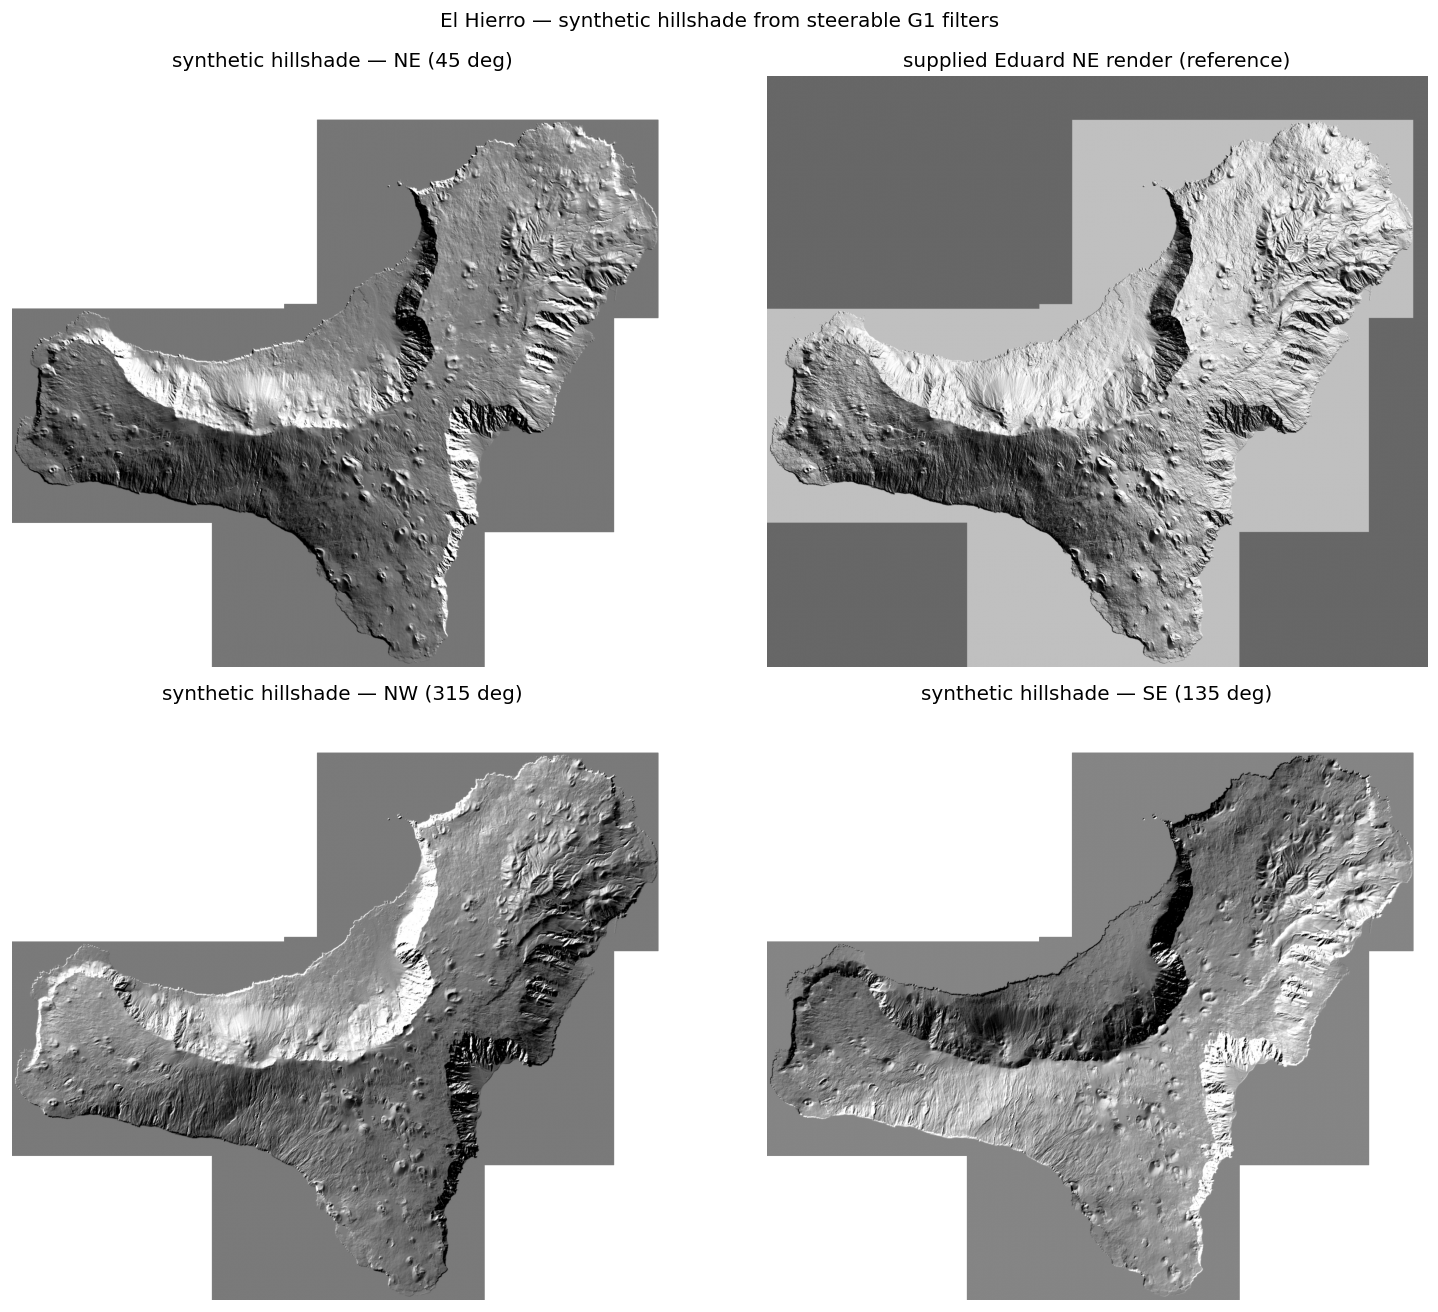

In [ ]:
# Step 2 - synthetic hillshade via steerable first-derivative-of-Gaussian filters
from scipy.ndimage import gaussian_filter

def dog_basis(dem, sigma=2):
    """The two steerable basis responses: G1^0 (d/dx) and G1^90 (d/dy)."""
    f = np.nan_to_num(dem)
    g0  = gaussian_filter(f, sigma, order=(0, 1))   # derivative along columns (east)
    g90 = gaussian_filter(f, sigma, order=(1, 0))   # derivative along rows (south)
    return g0, g90

def steer_hillshade(g0, g90, az_deg):
    """Relief shading lit from compass azimuth az_deg via G1^theta = cos.G1^0 + sin.G1^90."""
    A = np.radians(az_deg)
    d = np.sin(A) * g0 - np.cos(A) * g90            # steerable directional derivative
    # NOTE: tested - with +d the synthetic shading is INVERTED w.r.t. the Eduard render
    # (corr -0.81); negating the directional derivative flips it to bright-where-lit (corr +0.81).
    s = np.where(valid, -d, np.nan)                 # -d: bright where the surface faces the light
    lo, hi = np.nanpercentile(s, [2, 98])
    return np.clip((s - lo) / (hi - lo + 1e-9), 0, 1)

valid = ~np.isnan(dem_h)
g0, g90 = dog_basis(dem_h, sigma=2)                 # filtered once; reused for every azimuth

hs_ne = steer_hillshade(g0, g90, 45)
hs_nw = steer_hillshade(g0, g90, 315)
hs_se = steer_hillshade(g0, g90, 135)

# Test 1: synthetic NE vs the supplied Eduard NE render
eduard_ne = load_norm(HIERRO_REND / "Hierro-Eduard-Analytical-NE.tiff")
m = valid & np.isfinite(eduard_ne) & np.isfinite(hs_ne)
corr = np.corrcoef(hs_ne[m], eduard_ne[m])[0, 1]
print(f"sigma = 2 px (~10 m); two base filters reused for all azimuths")
print(f"corr(synthetic NE hillshade, Eduard NE render) = {corr:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 11)); ax = axes.ravel()
ax[0].imshow(hs_ne, cmap="gray"); ax[0].set_title("synthetic hillshade - NE (45 deg)")
ax[1].imshow(eduard_ne, cmap="gray"); ax[1].set_title("supplied Eduard NE render (reference)")
ax[2].imshow(hs_nw, cmap="gray"); ax[2].set_title("synthetic hillshade - NW (315 deg)")
ax[3].imshow(hs_se, cmap="gray"); ax[3].set_title("synthetic hillshade - SE (135 deg)")
for a in ax: a.axis("off")
fig.suptitle("El Hierro - synthetic hillshade from steerable G1 filters", y=0.99)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_steerable.png", dpi=120, bbox_inches="tight")
plt.show()

**What we see.** The synthetic NE hillshade reproduces the Eduard NE render (corr $\approx 0.81$) from just **two** Gaussian-derivative filters, and rotating $\theta$ swings the illumination and shadows coherently (NE vs NW vs SE). 

This gives us a **CV-grounded, self-produced** multi-direction shading we control — unlike the fixed NE/NW renders — useful to make the cone flanks pop from any light angle in the next steps.

> **Technical note (tested).** With the raw directional derivative the synthetic shading comes out *inverted* relative to the Eduard render (corr $-0.81$): our light-direction convention is opposite to theirs. Negating it (`s = -d`, bright where the surface faces the light) flips the sign to corr $+0.81$, matching Eduard.